In [1]:
import subprocess
import json
import os
from hipporag import HippoRAG


 # Decrypt and load environment variables from dotenvx
result = subprocess.run(['dotenvx', 'get', '--format', 'json'], capture_output=True,
text=True)

if result.returncode == 0:
    env_vars = json.loads(result.stdout)
    for key, value in env_vars.items():
        os.environ[key] = value
    print("✅ dotenvx variables loaded successfully!")
else:
    print(f"❌ Error loading dotenvx variables: {result.stderr}")

/Users/juanhorma97/vector_graphRAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-03 13:42:58,621	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


✅ dotenvx variables loaded successfully!


In [2]:
%load_ext autoreload
%autoreload 2

import asyncio
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import openai
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type
from src.config import Config
from src.clients import get_clients
from src.utils import process_pptx_file, generate_prompt
from src.rag_adapters import VectorRAGAdapter, LightRAGAdapter, HippoRAGAdapter, SpannerGraphRAGAdapter, AgenticRAGAdapter
from src.evaluation import add_eval_dataset, evaluate_retrieval
from vectorGraphRag import initialize_lightrag, initialize_dataframe

/Users/juanhorma97/vector_graphRAG/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# Initialize graphRAG and DataFrame

In [3]:
Config.setup_directories()
clients = get_clients()

hipporag = HippoRAG(
    # llm_model_name="gpt-4o-mini-2024-07-18",
    # embedding_model_name="text-embedding-3-small"
    llm_model_name=Config.LLM_MODEL,
    llm_base_url=Config.LLM_BINDING_HOST,
    embedding_model_name=Config.EMBEDDING_MODEL,
    embedding_base_url=Config.EMBEDDING_BINDING_HOST
)

lightrag = await initialize_lightrag()

adapters = {
    "vector_rag": VectorRAGAdapter(clients.qdrant_client, clients.embedding_service),
    "lightrag": LightRAGAdapter(lightrag),
    "hipporag": HippoRAGAdapter(hipporag),
    "spanner_graph": SpannerGraphRAGAdapter(
        clients.graph_store,
        clients.embedding_service,
        clients.llm_transformer,
        Config.GRAPH_NAME
    ),
    "agentic_rag": AgenticRAGAdapter(clients.qdrant_client, clients.embedding_service)
}

df = initialize_dataframe("./templates/CrossDoc_RAG_Benchmark.csv", list(adapters.keys()))

directory_path = "./documents_to_index"
file_paths = [
    os.path.join(directory_path, f)
    for f in os.listdir(directory_path)
    if os.path.isfile(os.path.join(directory_path, f))
]

contents = process_pptx_file(file_paths)



INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './data/rag_storage/vdb_entities.json'} 0 data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './data/rag_storage/vdb_relationships.json'} 0 data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './data/rag_storage/vdb_chunks.json'} 0 data
INFO: [_] Process 51747 KV load full_docs with 0 records
INFO: [_] Process 51747 KV load text_chunks with 0 records
INFO: [_] Process 51747 KV load full_entities with 0 records
INFO: [_] Process 51747 KV load full_relations with 0 records
INFO: [base] Connected to chunk-entity-relation at bolt://54.224.40.47:7687
INFO: [base] Ensured B-Tree index on entity_id for base in chunk-entity-relation
INFO: [base] Found existing index 'entity_id_fulltext_idx' with state: ONLINE
INFO: [base] Full-text index 'entity_id_fulltext_idx' already exists and is online. Skipping recreation.
INFO: [_] Process 51747 KV l

# Generate vector and graph RAG indexes


In [4]:
indexing_intervals = {}

for name, adapter in adapters.items():
    start_time = datetime.datetime.now()
    await adapter.index(contents)
    indexing_intervals[name] = (datetime.datetime.now() - start_time).total_seconds()

index_interval_dataframe = pd.DataFrame(
    indexing_intervals,
    index=["indexing_time"]
)


INFO: Processing 509 document(s)
INFO: Extracting stage 1/509: unknown_source
INFO: Processing d-id: doc-250fb38ae6fb3208c5fe66305be6f186
INFO: Extracting stage 2/509: unknown_source
INFO: Processing d-id: doc-19b4df6b221ff25c3eb968bafad6f698
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: LLM func: 4 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)
INFO:  == LLM cache == saving: default:extract:98d0c12e0e38062cc1497988c012d424
INFO:  == LLM cache == saving: default:extract:9b9b66f70cce5607d7386659e267bf00
INFO:  == LLM cache == saving: default:extract:58fdbb348dad5e4f69bd3a28d313a142
INFO: Chunk 1 of 1 extracted 2 Ent + 1 Rel chunk-19b4df6b221ff25c3eb968bafad6f698
INFO: Merging stage 2/509: unknown_source
INFO: Phase 1: Processing 2 entities from doc-19b4df6b221ff25c3eb968bafad6f698 (async: 8)
INFO: Merged: `Go Live` | 5+1
INFO: Merged: `1994` | 5+1
INFO: Phase 2: Processing 1 relations from do

{'num_phrase_nodes': 859, 'num_passage_nodes': 509, 'num_total_nodes': 1368, 'num_extracted_triples': 1003, 'num_triples_with_passage_node': 1262, 'num_synonymy_triples': 1223, 'num_total_triples': 3488}
Cleaning up graph store before indexing...
Waiting for DDL operations to complete...
Waiting for DDL operations to complete...
Waiting for DDL operations to complete...
Starting Spanner graph extraction for 969 documents...
Extracting graph for document 1/969...
Extracting graph for document 2/969...
Extracting graph for document 3/969...
Extracting graph for document 4/969...
Extracting graph for document 5/969...
Successfully extracted graph for document 3.
Extracting graph for document 6/969...
Successfully extracted graph for document 1.
Extracting graph for document 7/969...
Successfully extracted graph for document 7.
Extracting graph for document 8/969...
Successfully extracted graph for document 6.
Extracting graph for document 9/969...
Successfully extracted graph for document

# Retrieve contexts

In [5]:
retrieval_intervals = {name: [] for name in adapters.keys()}

for i in range(df.shape[0]):
    query = str(df.at[i, "query"])
    await asyncio.sleep(1)

    for name, adapter in adapters.items():
        start_time = datetime.datetime.now()
        context = await adapter.retrieve(query)
        retrieval_intervals[name].append((datetime.datetime.now() - start_time).total_seconds()) 
        df.at[i, f"results_{name}"] = context


retrieval_interval_dataframe = pd.DataFrame(
    retrieval_intervals,
    index=list(df["query_id"])
)

    

INFO:  == LLM cache == saving: mix:keywords:4605480942a64cfedb230bb896b25fa3
INFO: Query nodes: Konecta, Repsol, Go live date, AI tools, Repsol case (top_k:3, cosine:0.2)
INFO: Local query: 3 entites, 80 relations
INFO: Query edges: Konecta Repsol collaboration, Project implementation details, AI technology application, Business case analysis (top_k:3, cosine:0.2)
INFO: Global query: 4 entites, 3 relations
INFO: Naive query: 3 chunks (chunk_top_k:3 cosine:0.2)
INFO: Raw search results: 6 entities, 82 relations, 3 vector chunks
INFO: After truncation: 3 entities, 5 relations
INFO: Selecting 9 from 60 entity-related chunks by weighted polling
INFO: Find 10 additional chunks in 4 relations (deduplicated 2)
INFO: Selecting 10 from 10 relation-related chunks by weighted polling
INFO: Round-robin merged chunks: 14 -> 13 (deduplicated 1)
INFO: Final context: 3 entities, 5 relations, 1 chunks
INFO: Final chunks S+F/O: E2/2
INFO:hipporag.HippoRAG:Preparing for fast retrieval.
INFO:hipporag.Hipp

Error parsing field fact_after_filter: 1 validation error for Fact
  Input should be a valid dictionary or instance of Fact [type=model_type, input_value='{"fact":[["konecta","has internal', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/model_type.

		On attempting to parse the value
```
{"fact":[["konecta","has internal
```
Failed to fetch connected chunks for node Konecta'S Internal Tools: 400 Syntax error: Expected keyword INSERT or keyword RETURN but got identifier \"S\" [at 4:42]\n                WHERE node.id = \'Konecta\'S Internal Tools\'\n                                         ^, request_id = 1.13319131638133517161.1.1.260.1 [locale: "en-US"
message: "Syntax error: Expected keyword INSERT or keyword RETURN but got identifier \"S\" [at 4:42]\n                WHERE node.id = \'Konecta\'S Internal Tools\'\n                                         ^"
]


INFO:  == LLM cache == saving: mix:keywords:ac6bcaf493483a2aede35415102e5ae5
INFO: Query nodes: Endesa, Go-live year, Dual-shore delivery, Delivery locations (top_k:3, cosine:0.2)
INFO: Local query: 3 entites, 11 relations
INFO: Query edges: Endesa case study, Project implementation details, Global delivery strategy (top_k:3, cosine:0.2)
INFO: Global query: 4 entites, 3 relations
INFO: Naive query: 3 chunks (chunk_top_k:3 cosine:0.2)
INFO: Raw search results: 7 entities, 14 relations, 3 vector chunks
INFO: After truncation: 6 entities, 14 relations
INFO: Selecting 13 from 13 entity-related chunks by weighted polling
INFO: Find no additional relations-related chunks from 14 relations
INFO: Round-robin merged chunks: 12 -> 9 (deduplicated 3)
INFO: Final context: 6 entities, 14 relations, 1 chunks
INFO: Final chunks S+F/O: E3/2
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_fact.
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_passage.
Retrieving: 100%|██████████| 1/1 [00:0

Error parsing field fact_after_filter: 1 validation error for Fact
  Input should be a valid dictionary or instance of Fact [type=model_type, input_value='{"fact":[["industry","is","retail   e commerce', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/model_type.

		On attempting to parse the value
```
{"fact":[["industry","is","retail   e commerce
```


INFO:  == LLM cache == saving: mix:keywords:29e7b3714964814d78b71868cbf4e32d
INFO: Query nodes: Italian Public Sector client, Italian Utilities client, Manager name (top_k:3, cosine:0.2)
INFO: Local query: 3 entites, 35 relations
INFO: Query edges: Account manager, Client management, Client portfolio (top_k:3, cosine:0.2)
INFO: Global query: 5 entites, 3 relations
INFO: Naive query: 3 chunks (chunk_top_k:3 cosine:0.2)
INFO: Raw search results: 8 entities, 38 relations, 3 vector chunks
INFO: After truncation: 5 entities, 17 relations
INFO: Selecting 7 from 7 entity-related chunks by weighted polling
INFO: Find 1 additional chunks in 1 relations (deduplicated 3)
INFO: Selecting 1 from 1 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 9 -> 8 (deduplicated 1)
INFO: Final context: 5 entities, 17 relations, 0 chunks
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_fact.
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_passage.
Retrieving: 100%|██████

Error parsing field fact_after_filter: 1 validation error for Fact
  Input should be a valid dictionary or instance of Fact [type=model_type, input_value='{"fact":[["cliente promotor","', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/model_type.

		On attempting to parse the value
```
{"fact":[["cliente promotor","
```


INFO:  == LLM cache == saving: mix:keywords:54eb4fbb46d429a5074a82502bc396ce
INFO: Query nodes: Retail clients, E-Commerce clients, two different clients (top_k:3, cosine:0.2)
INFO: Local query: 3 entites, 12 relations
INFO: Query edges: Account manager, Client relationships, Inventory data (top_k:3, cosine:0.2)
INFO: Global query: 6 entites, 3 relations
INFO: Naive query: 3 chunks (chunk_top_k:3 cosine:0.2)
INFO: Raw search results: 9 entities, 15 relations, 3 vector chunks
INFO: After truncation: 2 entities, 11 relations
INFO: Selecting 6 from 8 entity-related chunks by weighted polling
INFO: Find 5 additional chunks in 4 relations (deduplicated 0)
INFO: Selecting 5 from 5 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 13 -> 11 (deduplicated 2)
INFO: Final context: 2 entities, 11 relations, 3 chunks
INFO: Final chunks S+F/O: R1/1 E1/2 C1/2
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_fact.
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to

Error parsing field fact_after_filter: 1 validation error for Fact
  Input should be a valid dictionary or instance of Fact [type=model_type, input_value='{"fact":[["agents","iden...ed","areas of shortfall', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/model_type.

		On attempting to parse the value
```
{"fact":[["agents","identified","areas of shortfall
```


INFO:  == LLM cache == saving: mix:keywords:03948eb8804bfb9988e31ccfd1808420
INFO: Query nodes: distinct portfolio offerings, non-Iberia European clients, most common (top_k:3, cosine:0.2)
INFO: Local query: 3 entites, 83 relations
INFO: Query edges: Konecta, Portfolio offerings, European clients (top_k:3, cosine:0.2)
INFO: Global query: 4 entites, 3 relations
INFO: Naive query: 3 chunks (chunk_top_k:3 cosine:0.2)
INFO: Raw search results: 7 entities, 86 relations, 3 vector chunks
INFO: After truncation: 3 entities, 15 relations
INFO: Selecting 9 from 13 entity-related chunks by weighted polling
INFO: Find 8 additional chunks in 6 relations (deduplicated 3)
INFO: Selecting 8 from 8 relation-related chunks by weighted polling
INFO: Round-robin merged chunks: 17 -> 16 (deduplicated 1)
INFO: Final context: 3 entities, 15 relations, 1 chunks
INFO: Final chunks S+F/O: R1/7
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_fact.
INFO:hipporag.HippoRAG:Encoding 1 queries for query_to_pas

# Print retrieval results

In [6]:
for i in range(df.shape[0]):
    print(f"\nQuery: {df.at[i, "query"]}\n")
    for name in adapters.keys():
        print(f"results from {name}: {df.at[i, f'results_{name}']}\n\n")


Query: When did Konecta go live with Repsol, and which AI tools does the Repsol case describe?

results from vector_rag: ['Konecta ha alcanzado un hito importante con Repsol al gestionar una operación de Contact Center y Back Office multicanal a gran escala en España y Portugal. Además de estas regiones principales, el alcance también incluye una operación de atención al cliente a pequeña escala para el mercado mexicano. Con aproximadamente 1000 agentes distribuidos en 6 centros, el servicio abarca áreas especializadas como Multienergía, Electricidad, Gas y servicios de emergencia 24/7. Un desafío clave fue el complejo plan de migración, que comenzó en febrero de 2025 y finalizó con éxito en octubre de 2025. Tras la estabilización operativa, Konecta está impulsando un Plan de Mejora del Servicio mediante la integración de IA. El proyecto continúa evolucionando con una hoja de ruta centrada en la automatización de los procesos de Back Office.', "- Flexibility and adaptability to meet c

# Generate LLM responses

In [7]:
async_openai_client = clients.async_openai_client

@retry(wait=wait_exponential(min=4, max=60), stop=stop_after_attempt(10), retry=retry_if_exception_type(openai.RateLimitError))
async def safe_completion(prompt: str):
    return await async_openai_client.responses.create(
        model=Config.LLM_MODEL, # type:ignore
        input=[{"role":"user", "content":prompt}]
    )
for i in range(df.shape[0]):
    query = str(df.at[i, "query"])

    tasks = []
    names = []
    await asyncio.sleep(1)
    for name in adapters.keys():
        if name == "agentic_rag":
            df.at[i, f"actual_responses_{name}"] = adapters[name].get_response(query)
            continue
        context = df.at[i, f"results_{name}"]
        prompt = generate_prompt(query, context) # type: ignore
        names.append(name)
        tasks.append(safe_completion(prompt))
    
    responses = await asyncio.gather(*tasks)
    for name, response in zip(names, responses):
        df.at[i, f"actual_responses_{name}"] = response.output_text
        

# Add dataset objects to DataFrame for eval

In [8]:
strategies = list(adapters.keys())
add_eval_dataset(df, strategies)

# Perform retrieval evaluation

/Users/juanhorma97/vector_graphRAG/src/evaluation.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=breakdown_df, x="system", y="avg_score", ax=ax_breakdown, palette="Set2")
/Users/juanhorma97/vector_graphRAG/src/evaluation.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=breakdown_df, x="system", y="avg_score", ax=ax_breakdown, palette="Set2")
/Users/juanhorma97/vector_graphRAG/src/evaluation.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=breakdown_df, x="system", y="avg_score", ax=ax_breakdown, palette="Set2"

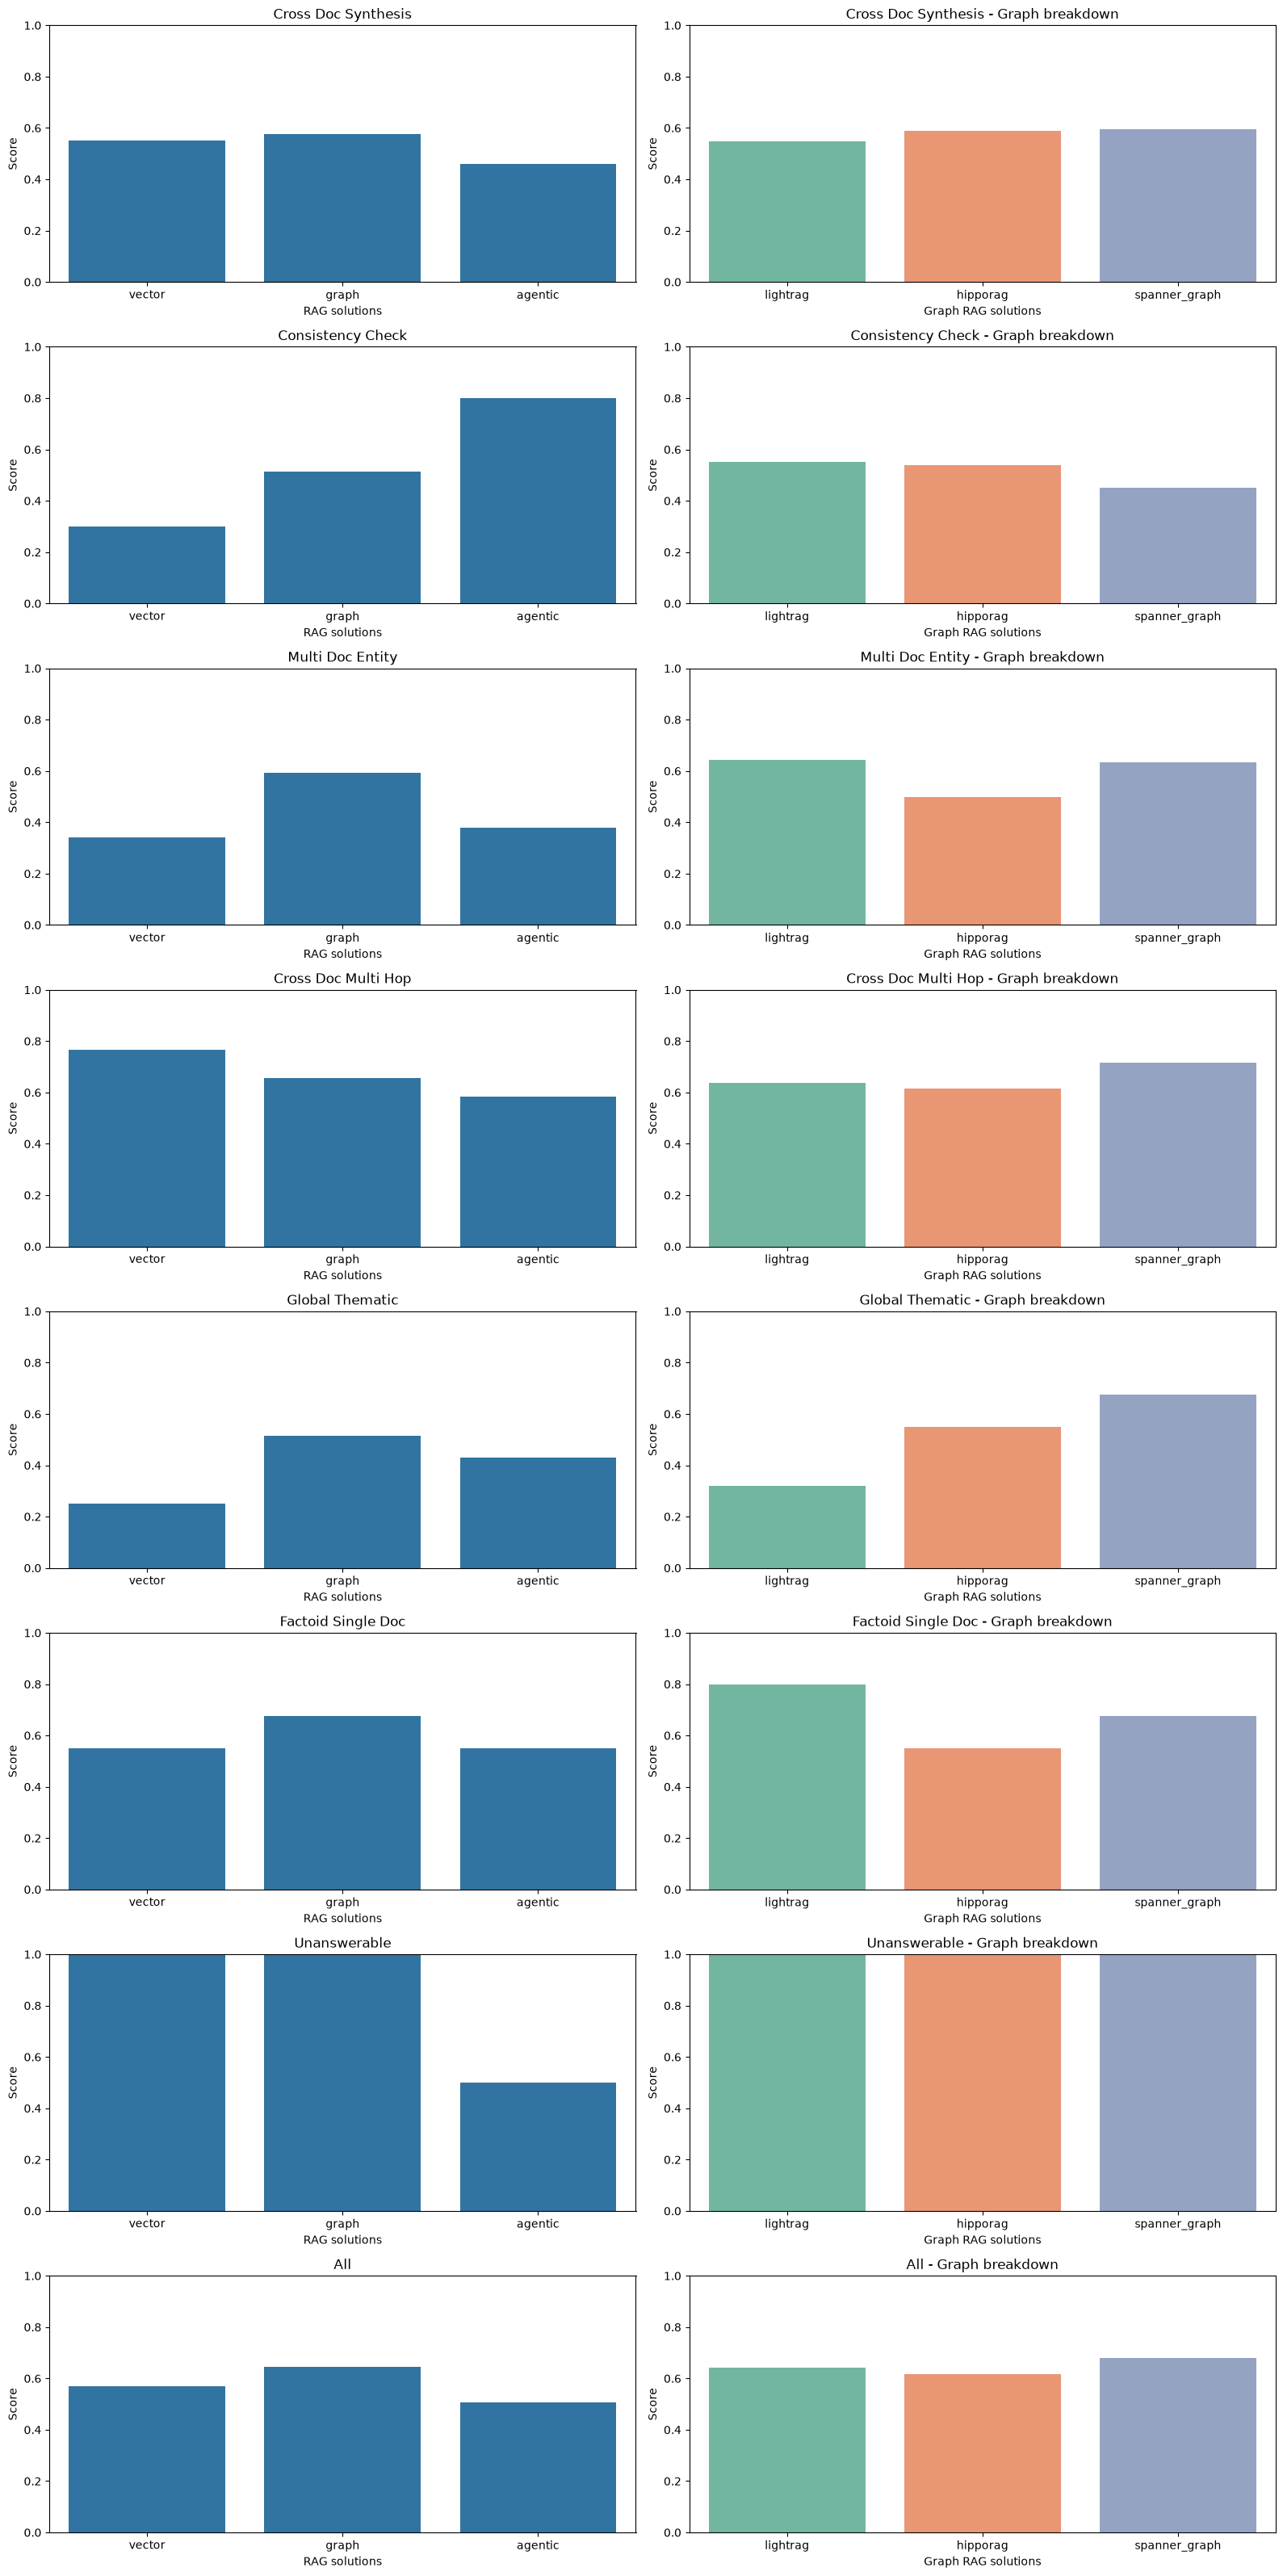

In [9]:
retrieval_interval_dataframe = await evaluate_retrieval(df, retrieval_interval_dataframe, async_openai_client, strategies)

# Create interval DataFrame 

In [10]:

interval_data = pd.concat([index_interval_dataframe.T, retrieval_interval_dataframe.T], axis=1)

# Generate interval plots

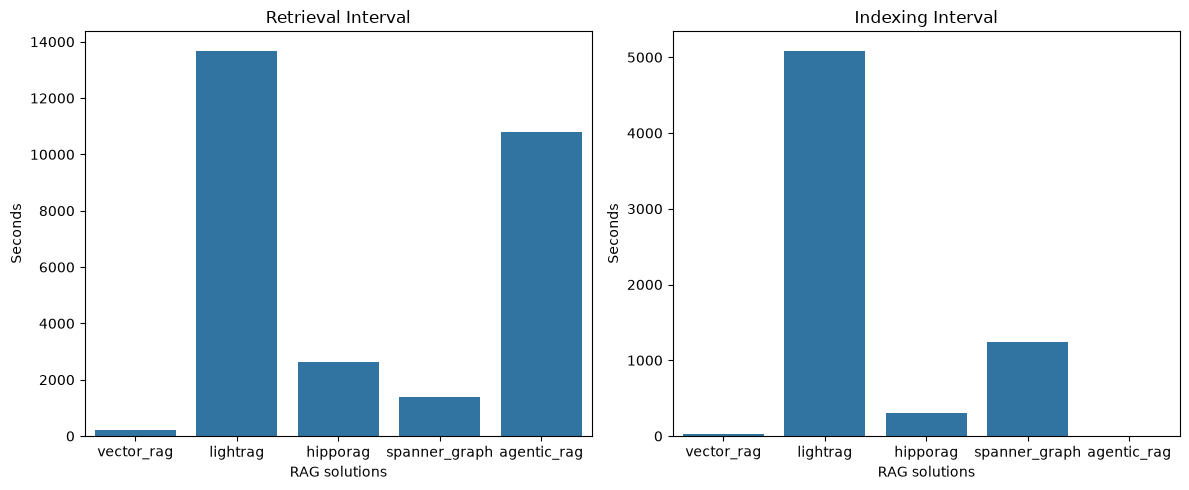

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot1 = sns.barplot(x=interval_data.index, y=interval_data["retrieval_time"], ax=axes[0])
axes[0].set_title("Retrieval Interval")
plot2 = sns.barplot(x=interval_data.index, y=interval_data["indexing_time"], ax=axes[1])
axes[1].set_title("Indexing Interval")

plot1.set(xlabel="RAG solutions", ylabel="Seconds")
plot2.set(xlabel="RAG solutions", ylabel="Seconds")
plt.tight_layout()
plt.show()